In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

In [123]:
#loaded the dataset
df=pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [125]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [126]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [127]:
#separating independent & dependent variables
X=df.iloc[:, 1:-1].values
y=df.iloc[:, -1].values
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


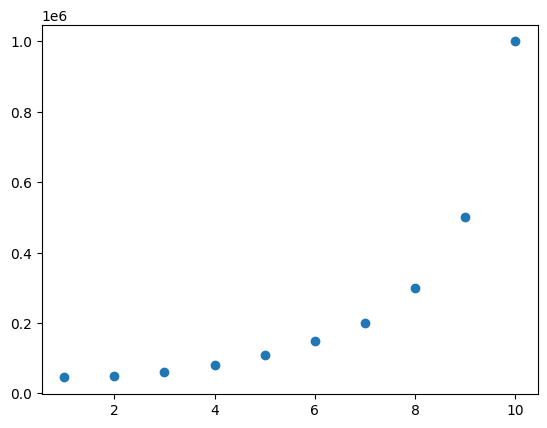

In [128]:
#check linearity
plt.scatter(X,y)

In [129]:
#splitting dataset
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(X_test)

[[ 6]
 [ 1]
 [ 8]
 [ 3]
 [10]
 [ 5]
 [ 4]
 [ 7]]
[[9]
 [2]]


In [130]:
#training model
regr=DecisionTreeRegressor(random_state=42)
regr.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [131]:
#predicting with model
y_pred=regr.predict(X_test)
print(y_pred)

[300000.  45000.]


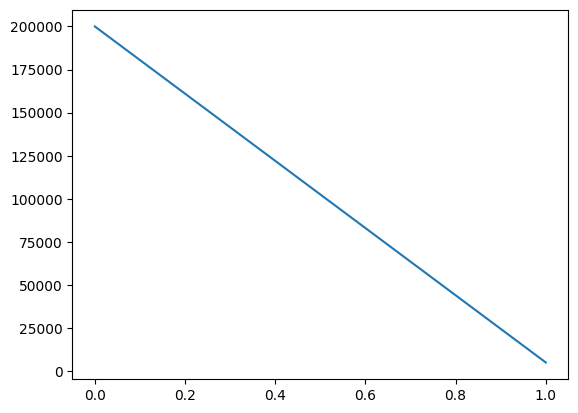

In [132]:
residual=y_test-y_pred
plt.plot(residual)


<Axes: ylabel='Density'>

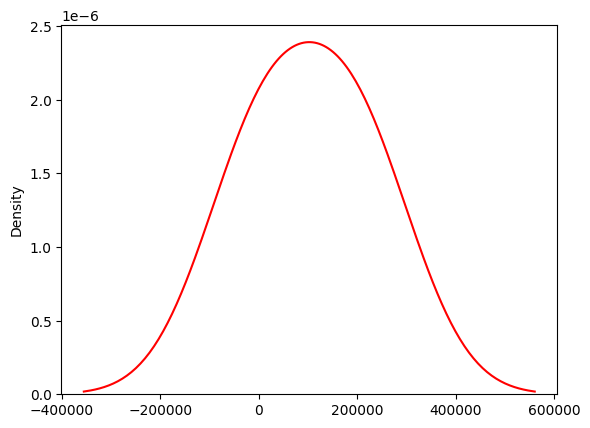

In [133]:
sns.kdeplot(residual, color='red')

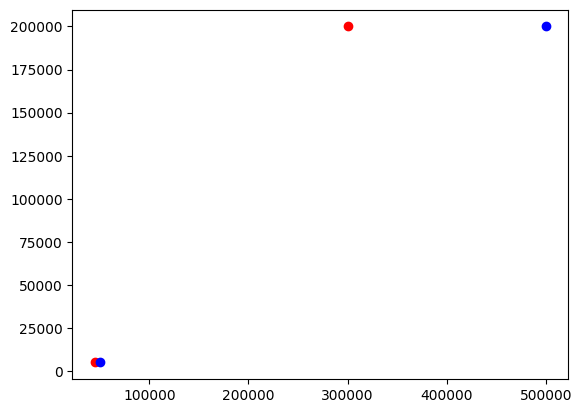

In [134]:
#checking homoscedasticity
plt.scatter(y_pred, residual, color='red')
plt.scatter(y_test, residual, color='blue')

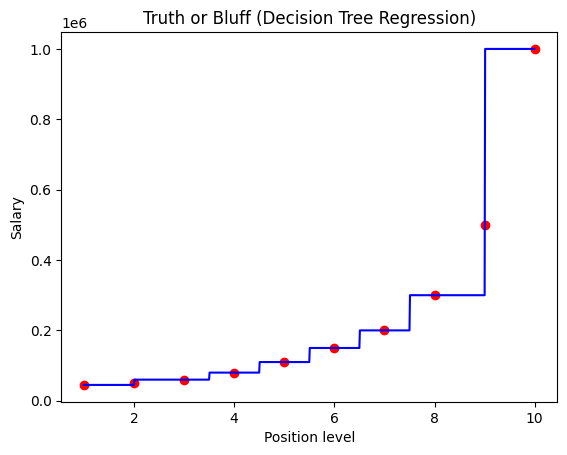

In [135]:
# Visualising the Decision Tree Regression results (higher resolution)
X_grid = np.arange(X.min(), X.max(), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, regr.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.savefig('decision_tree_reg.png')
plt.show()

In [136]:
#evaluation metrics
score= r2_score(y_test, y_pred)
print(f"R2 Score: {score}")
rmse=root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

R2 Score: 0.6046913580246913
RMSE: 141465.54350795108
